In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
np.random.seed(42)  # this makes sure we get the same random data every time

# we start by Generating 10,000 fake flights
num_flights = 10000

# Flight details
airlines = ['Delta', 'United', 'American', 'Southwest', 'JetBlue']
airports = ['JFK', 'LAX', 'ORD', 'DFW', 'ATL', 'DEN', 'SFO', 'SEA']
weather = ['Clear', 'Cloudy', 'Rain', 'Snow', 'Fog']

# create our data table
flights = pd.DataFrame({
    'airline': np.random.choice(airlines, num_flights),
    'origin': np.random.choice(airports, num_flights),
    'destination': np.random.choice(airports, num_flights),
    'hour': np.random.randint(0, 24, num_flights),  # hour of departure
    'day': np.random.randint(1, 8, num_flights),  # day of week
    'distance': np.random.randint(100, 3000, num_flights),  # miles
    'weather': np.random.choice(weather, num_flights, p=[0.5, 0.2, 0.15, 0.1, 0.05])  # weather probabilities
})

print("Here's what our flight data looks like:")
print(flights.head())

Here's what our flight data looks like:
     airline origin destination  hour  day  distance weather
0  Southwest    LAX         JFK    22    1      1528    Snow
1    JetBlue    DEN         SFO    14    4      2543   Clear
2   American    SFO         SEA     6    3       878   Clear
3    JetBlue    DFW         ATL     3    3      2841   Clear
4    JetBlue    ATL         SEA    11    2       310   Clear



Delay information:
       delay_minutes    is_delayed
count   10000.000000  10000.000000
mean       15.938954      0.455000
std        13.979653      0.497996
min         0.000000      0.000000
25%         4.019981      0.000000
50%        13.318229      0.000000
75%        24.680977      1.000000
max        78.679831      1.000000


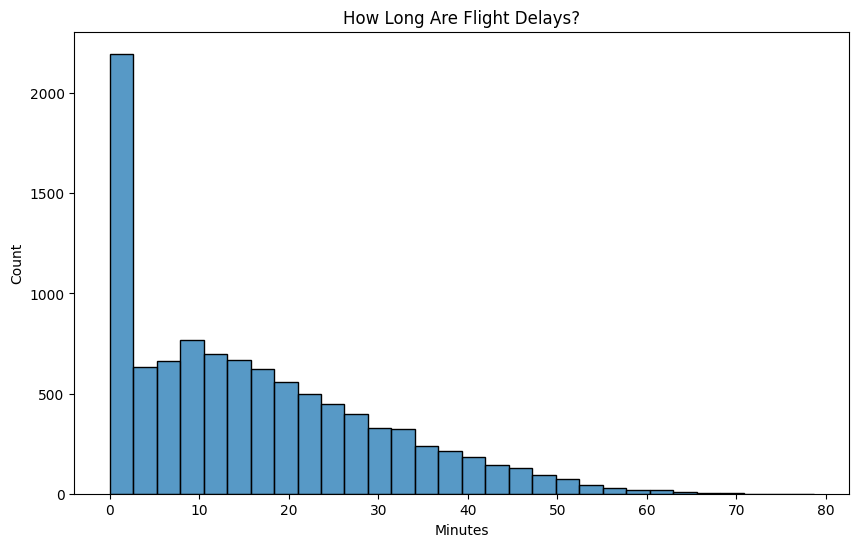

In [ ]:
# decide which flights are delayed based on patterns
# bad weather means more delays
# rush hours means more delays
# some airlines equals more delays

# start with no delays
flights['delay_minutes'] = np.random.normal(5, 10, num_flights)  # Base delay

# then we add weather delays
flights.loc[flights['weather'] == 'Rain', 'delay_minutes'] += 15
flights.loc[flights['weather'] == 'Snow', 'delay_minutes'] += 30
flights.loc[flights['weather'] == 'Fog', 'delay_minutes'] += 25

# and last we add rush hour delays
flights.loc[(flights['hour'] >= 6) & (flights['hour'] <= 9), 'delay_minutes'] += 10
flights.loc[(flights['hour'] >= 16) & (flights['hour'] <= 19), 'delay_minutes'] += 10

# make sure delays aren't negative
flights['delay_minutes'] = flights['delay_minutes'].clip(0)

# create a simple "is delayed" column (more than 15 minutes =then the flight is delayed)
flights['is_delayed'] = (flights['delay_minutes'] > 15).astype(int)

# look at our delays
print("\nDelay information:")
print(flights[['delay_minutes', 'is_delayed']].describe())

# make a simple chart
plt.figure(figsize=(10, 6))
sns.histplot(flights['delay_minutes'], bins=30)
plt.title('How Long Are Flight Delays?')
plt.xlabel('Minutes')
plt.show()

In [ ]:
# convert words to numbers
flights_encoded = pd.get_dummies(flights, columns=['airline', 'origin', 'destination', 'weather'])

# separate our features ( what we know ) from our answers ( what we want to predict )
X = flights_encoded.drop(['delay_minutes', 'is_delayed'], axis=1)
y_classify = flights_encoded['is_delayed']  # will it be delayed? ( yes or no )
y_regress = flights_encoded['delay_minutes']  # how long will it be delayed? ( in minutes )

# split into practice and test sets (80% practice and 20% test)
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_classify, y_regress, test_size=0.2, random_state=42)

print(f"Training with {len(X_train)} flights, testing with {len(X_test)} flights")

Training with 8000 flights, testing with 2000 flights


In [ ]:
# tool 1 : Will the flight be delayed? ( yes or no)
delay_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
delay_classifier.fit(X_train, y_class_train)

# tool 2 : how long will the delay be? ( in minutes )
delay_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
delay_regressor.fit(X_train, y_reg_train)

print("Prediction tools trained!")

Prediction tools trained!


Tool 1 accuracy: 75.65% of predictions were correct
Tool 2 is off by about 9.3 minutes on average

Top 10 factors that cause delays:
           Feature  Importance
2         distance    0.177642
0             hour    0.159556
28    weather_Snow    0.091719
24   weather_Clear    0.084784
1              day    0.084582
25  weather_Cloudy    0.056312
27    weather_Rain    0.053017
26     weather_Fog    0.036708
4    airline_Delta    0.013773
7   airline_United    0.013328


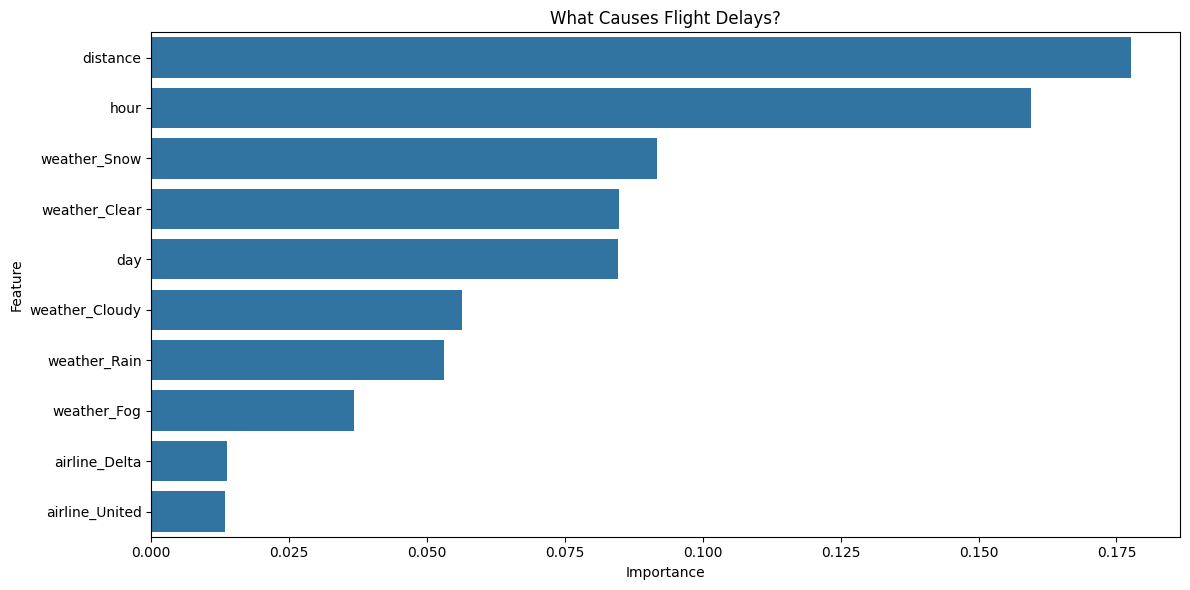

In [ ]:
# test tool 1 : Will it be delayed?
class_predictions = delay_classifier.predict(X_test)
class_accuracy = accuracy_score(y_class_test, class_predictions)

print(f"Tool 1 accuracy: {class_accuracy:.2%} of predictions were correct")

# test Tool 2 : How long will it be delayed?
reg_predictions = delay_regressor.predict(X_test)
# fixed version , calculate RMSE
reg_error = np.sqrt(mean_squared_error(y_reg_test, reg_predictions))

print(f"Tool 2 is off by about {reg_error:.1f} minutes on average")

# the factors that matter the most for delays
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': delay_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

# show top 10 factors
print("\nTop 10 factors that cause delays:")
print(feature_importance.head(10))

# make a simple chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('What Causes Flight Delays?')
plt.tight_layout()
plt.show()

In [ ]:
# save the trained tools
joblib.dump(delay_classifier, 'delay_predictor.pkl')
joblib.dump(delay_regressor, 'delay_time_predictor.pkl')

print("Tools saved! Now let's create a simple prediction function.")

def predict_flight_delay(airline, origin, destination, hour, day, distance, weather):
    # create a sample flight with the given details
    sample = pd.DataFrame({
        'airline': [airline],
        'origin': [origin],
        'destination': [destination],
        'hour': [hour],
        'day': [day],
        'distance': [distance],
        'weather': [weather]
    })

    # process the sample the same way we processed our training data
    sample_encoded = pd.get_dummies(sample, columns=['airline', 'origin', 'destination', 'weather'])

    # make sure all columns match
    for col in X.columns:
        if col not in sample_encoded.columns:
            sample_encoded[col] = 0

    # reorder columns to match training data
    sample_encoded = sample_encoded[X.columns]

    # then we make predictions
    will_delay = delay_classifier.predict(sample_encoded)[0]
    delay_time = delay_regressor.predict(sample_encoded)[0]

    # then we return results
    if will_delay:
        return f"Yes, this flight will likely be delayed by about {delay_time:.0f} minutes."
    else:
        return f"No, this flight will likely be on time (maybe {delay_time:.0f} minutes late)."

# and last we test our function
print("\nTesting our prediction tool:")
print(predict_flight_delay('Delta', 'JFK', 'LAX', 14, 3, 2475, 'Clear'))
print(predict_flight_delay('United', 'ORD', 'DFW', 8, 5, 802, 'Rain'))
print(predict_flight_delay('Southwest', 'ATL', 'DEN', 18, 2, 1198, 'Snow'))

Tools saved! Now let's create a simple prediction function.

Testing our prediction tool:
No, this flight will likely be on time (maybe 8 minutes late).
Yes, this flight will likely be delayed by about 31 minutes.
Yes, this flight will likely be delayed by about 43 minutes.


In [ ]:
# install gradio for a simple interface
!pip install gradio -q

import gradio as gr

# create a simple interface
iface = gr.Interface(
    fn=predict_flight_delay,
    inputs=[
        gr.Dropdown(choices=airlines, label="Airline"),
        gr.Dropdown(choices=airports, label="From"),
        gr.Dropdown(choices=airports, label="To"),
        gr.Slider(0, 23, step=1, label="Hour of Day"),
        gr.Slider(1, 7, step=1, label="Day of Week (1=Mon, 7=Sun)"),
        gr.Slider(100, 3000, step=50, label="Distance (miles)"),
        gr.Dropdown(choices=weather, label="Weather")
    ],
    outputs=gr.Textbox(label="Delay Prediction"),
    title="Flight Delay Predictor",
    description="Enter flight details to see if it will be delayed!"
)

# launch the interface
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://597e49488d244b7ed1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
